In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import Ridge, Lasso
from sklearn.linear_model import LassoCV
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV

In [3]:
RANDOM_STATE = 42

DATASET_PATH = "https://raw.githubusercontent.com/evgpat/stepik_from_idea_to_mvp/main/datasets/cars.csv"

pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [4]:
df = pd.read_csv(DATASET_PATH)

df.head(10)

KeyboardInterrupt: 

In [40]:
print('Размерность датасета:', df.shape, '\n')

df.info()

Размерность датасета: (6999, 13) 

<class 'pandas.DataFrame'>
RangeIndex: 6999 entries, 0 to 6998
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           6999 non-null   str    
 1   year           6999 non-null   int64  
 2   selling_price  6999 non-null   int64  
 3   km_driven      6999 non-null   int64  
 4   fuel           6999 non-null   str    
 5   seller_type    6999 non-null   str    
 6   transmission   6999 non-null   str    
 7   owner          6999 non-null   str    
 8   mileage        6797 non-null   str    
 9   engine         6797 non-null   str    
 10  max_power      6803 non-null   str    
 11  torque         6796 non-null   str    
 12  seats          6797 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 711.0 KB


In [41]:
df.describe()

,year,selling_price,km_driven,seats
count,6999.00,6999.00,6999.00,6797.00
mean,2013.82,639515.20,69584.62,5.42
std,4.05,808941.91,57724.00,0.97
min,1983.00,29999.00,1.00,2.00
25%,2011.00,254999.00,35000.00,5.00
50%,2015.00,450000.00,60000.00,5.00
75%,2017.00,675000.00,97000.00,5.00
max,2020.00,10000000.00,2360457.00,14.00


In [42]:
df.describe(include='object')

C:\Users\User\AppData\Local\Temp\ipykernel_6196\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,name,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque
count,6999,6999,6999,6999,6999,6797,6797,6803,6796
unique,1924,4,3,2,5,386,120,316,419
top,Maruti Swift Dzire VDI,Diesel,Individual,Manual,First Owner,18.9 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm
freq,116,3793,5826,6095,4587,197,885,330,468


In [43]:
#Факторы влияющие на цену машины

factors = ['name', 'year', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque', 'seats'] # - ?

In [44]:
df['seats'].value_counts(dropna=False)


seats
5.00     5393
7.00      944
8.00      208
NaN       202
4.00      104
9.00       72
6.00       54
10.00      19
2.00        2
14.00       1
Name: count, dtype: int64

In [45]:
mean_seats_int = int(df['seats'].mean())
df['seats'] = df['seats'].fillna(mean_seats_int)

df['seats'].value_counts(dropna=False)

seats
5.00     5595
7.00      944
8.00      208
4.00      104
9.00       72
6.00       54
10.00      19
2.00        2
14.00       1
Name: count, dtype: int64

In [46]:
df['name'] = df['name'].str.split().str[0]


counts = df['name'].value_counts()
rare_brands = counts[counts < 62].index
df['name'] = df['name'].replace(rare_brands, 'Other')

print('Кол-во пропущеных значений:', df['name'].isna().sum())
df['name'].value_counts(dropna=False)

Кол-во пропущеных значений: 0


name
Maruti        2126
Hyundai       1197
Mahindra       666
Tata           611
Toyota         426
Honda          404
Other          400
Ford           339
Chevrolet      204
Renault        196
Volkswagen     167
BMW            103
Skoda           90
Nissan          70
Name: count, dtype: int64

In [47]:
df['year'] = datetime.now().year - df['year']

print('Кол-во пропущеных значений:', df['year'].isna().sum())
df['year'].value_counts()

Кол-во пропущеных значений: 0


year
9     870
10    736
8     704
11    662
13    581
14    563
12    532
7     511
15    499
16    336
17    208
18    191
19    164
20    103
21     86
6      69
22     51
23     40
24     23
26     21
27     13
29     10
28      9
25      8
30      3
32      3
43      1
31      1
35      1
Name: count, dtype: int64

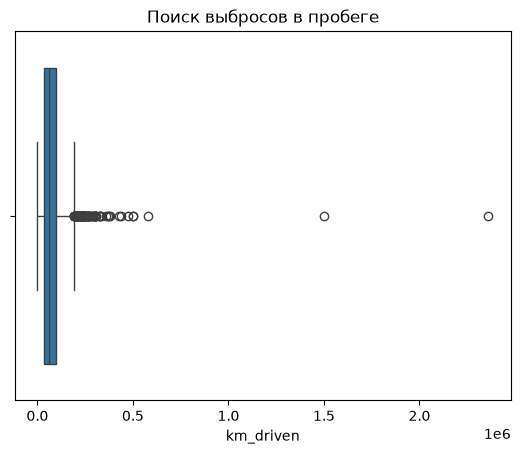

In [48]:
sns.boxplot(data=df, x='km_driven', orient='h')
plt.title('Поиск выбросов в пробеге')
plt.show()


Кол-во выбросов: 24
Кол-во пропущеных значений: 0


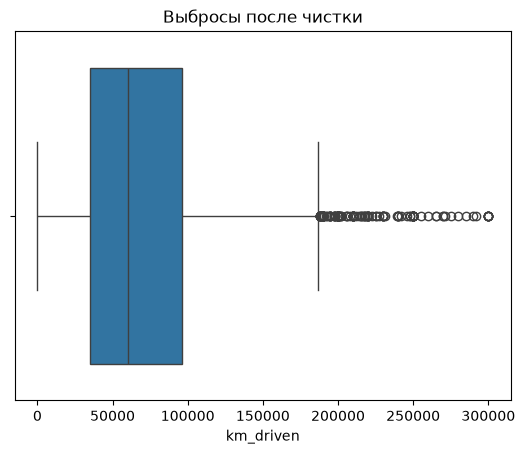

In [49]:
outliers_count = df[df['km_driven'] >= 300000].shape[0]
print('Кол-во выбросов:', outliers_count)

df = df[df['km_driven'] <= 300_000]
print('Кол-во пропущеных значений:', df['km_driven'].isna().sum())

sns.boxplot(data=df, x='km_driven', orient='h')
plt.title('Выбросы после чистки')
plt.show()

In [50]:
print('Кол-во пропущеных значений:', df['fuel'].isna().sum())
df['fuel'].value_counts(dropna=False)

Кол-во пропущеных значений: 0


fuel
Diesel    3782
Petrol    3114
CNG         52
LPG         34
Name: count, dtype: int64

In [51]:
df['mileage'] = df['mileage'].str.split().str[0]
df['mileage'] = df['mileage'].astype(float)
df['mileage'] = df['mileage'].replace(0, None)

median_mileage = df['mileage'].median()
df['mileage'] = df['mileage'].fillna(median_mileage)
df['mileage'] = df['mileage'].astype(float)

print('Кол-во пропущеных значений:', df['mileage'].isna().sum())


Кол-во пропущеных значений: 0


In [52]:
df['engine'] = df['engine'].str.split().str[0]
df['engine'] = df['engine'].astype(float)

median_mileage = df['engine'].median()
df['engine'] = df['engine'].fillna(median_mileage)

print('Кол-во пропущеных значений:', df['engine'].isna().sum())


Кол-во пропущеных значений: 0


In [53]:
df['max_power'] = df['max_power'].astype(str).str.split().str[0]
df['max_power'] = pd.to_numeric(df['max_power'], errors='coerce')
df['max_power'] = df['max_power'].replace(0, None)

median_power = df['max_power'].median()
df['max_power'] = df['max_power'].fillna(median_power)
df['max_power'] = df['max_power'].astype(float)

print("Осталось нулей:", (df['max_power'] == 0).sum())
print('Кол-во пропущеных значений:', df['max_power'].isna().sum())

Осталось нулей: 0
Кол-во пропущеных значений: 0


In [54]:
def extract_torque_features(text):
    if pd.isna(text) or not isinstance(text, str):
        return None, None
    
    text = text.lower().replace(',', '').strip()
    
    nm_match = re.search(r'([\d.]+)\s*(nm|kgm)', text)
    torque_val = None
    if nm_match:
        val = float(nm_match.group(1))
        unit = nm_match.group(2)
        if unit == 'kgm':
            val *= 9.80665
        torque_val = val
    else:
        first_num = re.search(r'^([\d.]+)', text)
        if first_num:
            torque_val = float(first_num.group(1))
            if torque_val < 50:
                torque_val *= 9.80665

    rpm_match = re.search(r'([\d.]+)\s*rpm', text)
    rpm_val = None
    if rpm_match:
        rpm_val = float(rpm_match.group(1))
    else:
        last_num = re.search(r'(?:@|at|\s)([\d.]+)\s*$', text)
        if last_num:
            rpm_val = float(last_num.group(1))
            
    return torque_val, rpm_val

In [55]:
torque_res = df['torque'].apply(extract_torque_features)
df['torque_nm'] = [x[0] for x in torque_res]
df['engine_rpm'] = [x[1] for x in torque_res]

df['torque_nm'] = df['torque_nm'].fillna(df['torque_nm'].median())
df['engine_rpm'] = df['engine_rpm'].fillna(df['engine_rpm'].median())

df = df.drop(columns=['torque'])

print(df[['torque_nm', 'engine_rpm']].head())

   torque_nm  engine_rpm
0     190.00     2000.00
1     250.00     2500.00
2     219.67     2750.00
3     112.78     3000.00
4     113.75     4000.00


In [56]:
df['transmission'].value_counts(dropna=False)

transmission
Manual       6078
Automatic     904
Name: count, dtype: int64

In [57]:
df['seller_type'].value_counts(dropna=False)

seller_type
Individual          5809
Dealer               967
Trustmark Dealer     206
Name: count, dtype: int64

In [58]:
# Влияние выбранных параметров на целевую переменную

base_numeric = ['selling_price', 'year', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'torque_nm', 'engine_rpm']

correlation = df[base_numeric].corr()['selling_price'].sort_values(ascending=False)
print("Влияние признаков на цену")
print(correlation)

print("\nСредняя цена в зависимости от коробки передач")
print(df.groupby('transmission')['selling_price'].mean().round())

print("\nСредняя цена в зависимости от типа топлива")
print(df.groupby('fuel')['selling_price'].mean().round())


Влияние признаков на цену
selling_price    1.00
max_power        0.75
torque_nm        0.62
engine           0.46
seats            0.05
engine_rpm      -0.03
mileage         -0.13
km_driven       -0.28
year            -0.41
Name: selling_price, dtype: float64

Средняя цена в зависимости от коробки передач
transmission
Automatic   1872489.00
Manual       456690.00
Name: selling_price, dtype: float64

Средняя цена в зависимости от типа топлива
fuel
CNG      294769.00
Diesel   791948.00
LPG      198412.00
Petrol   466047.00
Name: selling_price, dtype: float64


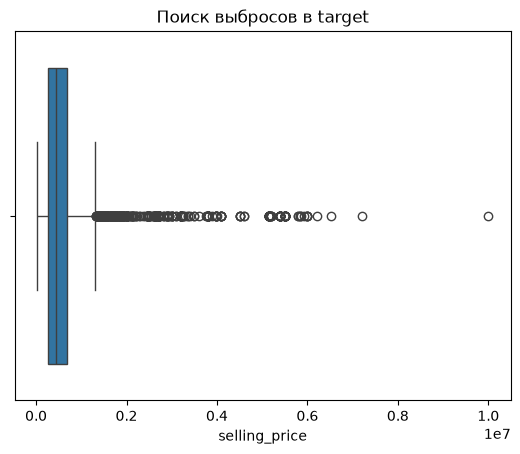

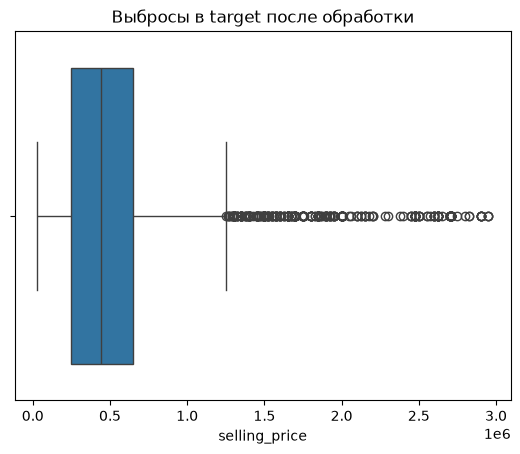

In [59]:
# Целевая переменная

sns.boxplot(data=df, x='selling_price', orient='h')
plt.title('Поиск выбросов в target')
plt.show()

df = df[df['selling_price'] < 3_000_000]

sns.boxplot(data=df, x='selling_price', orient='h')
plt.title('Выбросы в target после обработки')
plt.show()


In [60]:
owner_dict = {
    'Test Drive Car': 0,
    'First Owner': 1,
    'Second Owner': 2,
    'Third Owner': 3,
    'Fourth & Above Owner': 4
}

# Применяем замену
df['owner'] = df['owner'].map(owner_dict)
df['owner'].value_counts(dropna=False)

owner
1    4385
2    1780
3     471
4     143
0       1
Name: count, dtype: int64

In [61]:
df.sample(10)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,torque_nm,engine_rpm
4640,Other,8,320000,35000,Petrol,Individual,Manual,1,22.50,999.00,67.00,5.00,91.00,4250.00
1196,Nissan,10,495000,56832,Diesel,Dealer,Manual,1,19.87,1461.00,83.14,5.00,200.00,1750.00
1162,Maruti,17,130000,80000,Petrol,Individual,Manual,3,19.70,796.00,46.30,5.00,62.00,3000.00
5427,Hyundai,8,540000,4000,Petrol,Individual,Manual,1,18.90,1197.00,81.86,5.00,113.75,4000.00
6124,Hyundai,12,455999,32000,Petrol,Individual,Manual,1,18.90,1197.00,82.00,5.00,114.00,4000.00
579,Other,8,2475000,2000,Diesel,Dealer,Automatic,1,16.80,1984.00,150.00,5.00,350.00,2750.00
6681,Toyota,15,800000,60000,Diesel,Individual,Manual,1,12.80,2494.00,102.00,7.00,200.06,3000.00
2616,Other,8,300000,19000,Petrol,Individual,Manual,1,22.50,999.00,67.00,5.00,91.00,4250.00
3589,Ford,8,620000,15000,Petrol,Individual,Manual,1,20.40,1194.00,94.93,5.00,120.00,4250.00
5747,Maruti,14,310000,25000,Diesel,Individual,Manual,2,21.50,1248.00,88.80,5.00,200.00,1750.00


In [62]:
print(df.shape)
df.info()

(6780, 14)
<class 'pandas.DataFrame'>
Index: 6780 entries, 0 to 6998
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           6780 non-null   object 
 1   year           6780 non-null   int64  
 2   selling_price  6780 non-null   int64  
 3   km_driven      6780 non-null   int64  
 4   fuel           6780 non-null   str    
 5   seller_type    6780 non-null   str    
 6   transmission   6780 non-null   str    
 7   owner          6780 non-null   int64  
 8   mileage        6780 non-null   float64
 9   engine         6780 non-null   float64
 10  max_power      6780 non-null   float64
 11  seats          6780 non-null   float64
 12  torque_nm      6780 non-null   float64
 13  engine_rpm     6780 non-null   float64
dtypes: float64(6), int64(4), object(1), str(3)
memory usage: 794.5+ KB


In [63]:
categorical_cols = ['name', 'fuel', 'seller_type', 'transmission']

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

df.info()

<class 'pandas.DataFrame'>
Index: 6780 entries, 0 to 6998
Data columns (total 29 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   year                          6780 non-null   int64  
 1   selling_price                 6780 non-null   int64  
 2   km_driven                     6780 non-null   int64  
 3   owner                         6780 non-null   int64  
 4   mileage                       6780 non-null   float64
 5   engine                        6780 non-null   float64
 6   max_power                     6780 non-null   float64
 7   seats                         6780 non-null   float64
 8   torque_nm                     6780 non-null   float64
 9   engine_rpm                    6780 non-null   float64
 10  name_Chevrolet                6780 non-null   int64  
 11  name_Ford                     6780 non-null   int64  
 12  name_Honda                    6780 non-null   int64  
 13  name_Hyundai       

In [ ]:
X = df.drop(columns=['selling_price'])
y = df['selling_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

numeric_features = ['year', 'km_driven', 'owner', 'mileage', 'engine', 'max_power', 'seats', 'torque_nm', 'engine_rpm']

scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])

X_test[numeric_features] = scaler.transform(X_test[numeric_features])

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (5424, 28)
Размер тестовой выборки: (1356, 28)


In [65]:
# Линейная регрессия

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = mean_squared_error(y_test, y_pred_lr) ** 0.5

print('Коэфицент детерминации:', round(r2_lr, 2))
print('MAE:', round(mae_lr, 2))
print('RMSE:', round(rmse_lr, 2))

Коэфицент детерминации: 0.79
MAE: 131360.99
RMSE: 186830.13


In [66]:
# Ridge (L2)

model_rd = Ridge(alpha=1.0)
model_rd.fit(X_train, y_train)

y_pred_rd = model_rd.predict(X_test)

r2_rd = r2_score(y_test, y_pred_rd)
mae_rd = mean_absolute_error(y_test, y_pred_rd)
rmse_rd = mean_squared_error(y_test, y_pred_rd) ** 0.5

print('Коэфицент детерминации:', round(r2_rd, 2))
print('MAE:', round(mae_rd, 2))
print('RMSE:', round(rmse_rd, 2))


Коэфицент детерминации: 0.78
MAE: 131558.42
RMSE: 187417.51


In [67]:
# Lasso (L1)

lasso_model = Lasso(alpha=1.0, max_iter=10000)
lasso_model.fit(X_train, y_train)

lasso_preds = lasso_model.predict(X_test)

r2_ls = r2_score(y_test, lasso_preds)
mae_ls = mean_absolute_error(y_test, lasso_preds)
rmse_ls = mean_squared_error(y_test, lasso_preds) ** 0.5

print('Коэфицент детерминации:', round(r2_ls, 2))
print('MAE:', round(mae_ls, 2))
print('RMSE:', round(rmse_ls, 2))

Коэфицент детерминации: 0.79
MAE: 131365.11
RMSE: 186842.81


In [ ]:
# LassoCV

alphas = np.logspace(-2, 2, 100)

lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=RANDOM_STATE)
lasso_cv.fit(X_train, y_train)

lasso_cv_preds = lasso_cv.predict(X_test)

r2_lcv = r2_score(y_test, lasso_cv_preds)
mae_lcv = mean_absolute_error(y_test, lasso_cv_preds)
rmse_lcv = mean_squared_error(y_test, lasso_cv_preds) ** 0.5

print('Коэфицент детерминации:', round(r2_lcv, 2))
print('MAE:', round(mae_lcv, 2))
print('RMSE:', round(rmse_lcv, 2))
print('alpha:', lasso_cv.alpha_)

Коэфицент детерминации: 0.79
MAE: 131395.57
RMSE: 186936.62
alpha: 8.111308307896872


In [ ]:
# ElasticNet

elastic = ElasticNet(max_iter=10_000, random_state=RANDOM_STATE)

param_grid = {
    'alpha': np.logspace(-3, 2, 20),
    'l1_ratio': np.linspace(0.1, 0.9, 9)
}

grid_search = GridSearchCV(
    estimator=elastic,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
y_pred_en = best_model.predict(X_test)

r2_en = r2_score(y_test, y_pred_en)
mae_en = mean_absolute_error(y_test, y_pred_en)
rmse_en = mean_squared_error(y_test, y_pred_en) ** 0.5

print('Коэфицент детерминации:', round(r2_en, 2))
print('MAE:', round(mae_en, 2))
print('RMSE:', round(rmse_en, 2))

Коэфицент детерминации: 0.79
MAE: 131488.93
RMSE: 187192.43
